# Final Manning's N and Infiltration Analysis

This notebook demonstrates how to extract final Manning's N and preprocessed infiltration values from a reproducible example project. It also includes a regression check for multi-ring infiltration override polygons.

In [1]:
from pathlib import Path
import logging
import importlib
import sys
import types

repo_root = (
    Path.cwd().resolve().parent
    if Path.cwd().resolve().name == 'examples'
    else Path.cwd().resolve()
)

package = types.ModuleType('ras_commander')
package.__path__ = [str(repo_root / 'ras_commander')]
sys.modules.pop('ras_commander', None)
sys.modules['ras_commander'] = package
logging_config = importlib.import_module('ras_commander.LoggingConfig')
package.get_logger = logging_config.get_logger
package.setup_logging = logging_config.setup_logging
decorators = importlib.import_module('ras_commander.Decorators')
package.log_call = decorators.log_call
package.standardize_input = decorators.standardize_input

for logger_name in [
    'ras_commander.RasExamples',
    'ras_commander.hdf.HdfLandCover',
    'ras_commander.hdf.HdfInfiltration',
    'ras_commander.hdf.HdfBase',
]:
    logging.getLogger(logger_name).setLevel(logging.CRITICAL + 1)

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RasExamples = importlib.import_module('ras_commander.RasExamples').RasExamples
HdfLandCover = importlib.import_module('ras_commander.hdf.HdfLandCover').HdfLandCover
HdfInfiltration = importlib.import_module('ras_commander.hdf.HdfInfiltration').HdfInfiltration

print('Imports successful')

Imports successful


In [2]:
project_path = RasExamples.extract_project('BaldEagleCrkMulti2D')

geom_hdf = None
mesh_names = []
for candidate in sorted(project_path.glob('*.g*.hdf')):
    with h5py.File(candidate, 'r') as hdf_file:
        areas_group = hdf_file.get('Geometry/2D Flow Areas')
        if areas_group is None:
            continue
        current_mesh_names = [
            area_name
            for area_name, area in areas_group.items()
            if isinstance(area, h5py.Group) and 'Infiltration' in area
        ]
        if current_mesh_names:
            geom_hdf = candidate
            mesh_names = current_mesh_names
            break

assert geom_hdf is not None, 'No geometry HDF with preprocessed infiltration data found.'
print(f'Project: {project_path.name}')
print(f'Geometry HDF: {geom_hdf.name}')
print(f'Meshes with infiltration data: {mesh_names}')

Project: BaldEagleCrkMulti2D
Geometry HDF: BaldEagleDamBrk.g09.hdf
Meshes with infiltration data: ['BaldEagleCr']


## Preprocessed Per-Cell Manning's N

In [3]:
mann_df = HdfLandCover.get_preprocessed_mannings_n(geom_hdf)
assert len(mann_df) > 0, "Expected preprocessed Manning's n values."
print(f'Cells: {len(mann_df):,}')
print(
    f"N range: {mann_df['mannings_n'].min():.4f} to {mann_df['mannings_n'].max():.4f}"
)
print(f"Mean: {mann_df['mannings_n'].mean():.4f}")
stats = HdfLandCover.get_preprocessed_mannings_stats(geom_hdf)
stats

Cells: 19,597
N range: 0.0300 to 0.1500
Mean: 0.0674


,mesh_name,n_cells,min_n,max_n,mean_n,median_n,std_n
0,BaldEagleCr,19597,0.03,0.15,0.067352,0.06,0.025607


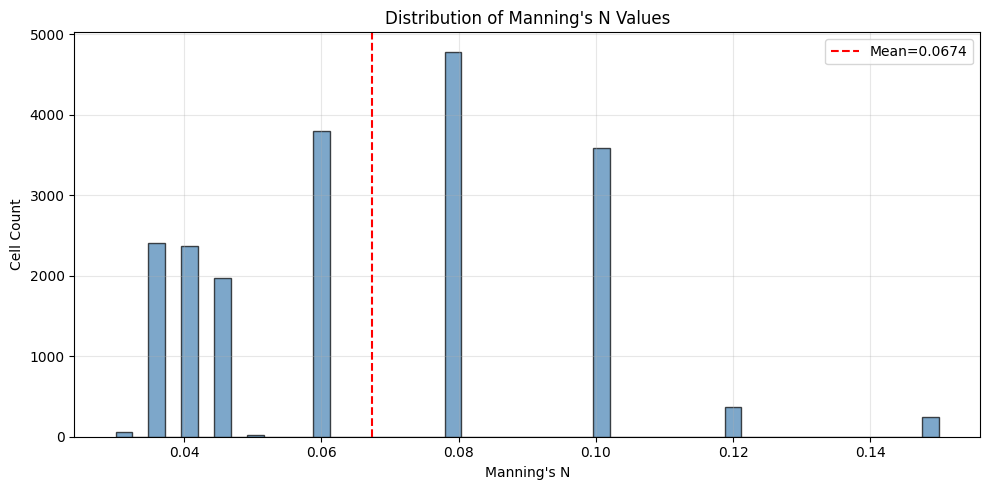

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    mann_df['mannings_n'],
    bins=50,
    edgecolor='black',
    alpha=0.7,
    color='steelblue',
)
ax.set_xlabel("Manning's N")
ax.set_ylabel('Cell Count')
ax.set_title("Distribution of Manning's N Values")
ax.axvline(
    mann_df['mannings_n'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean={mann_df['mannings_n'].mean():.4f}",
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close(fig)

## Calibration Table and Base vs Calibrated Comparison

In [5]:
cal = HdfLandCover.get_mannings_calibration_table(geom_hdf)
assert cal is not None and len(cal) > 0, "Expected Manning's calibration data."
print(f'Land cover classes: {len(cal)}, Calibration regions: {len(cal.columns) - 2}')
print()
print('Base values:')
print(cal.iloc[:, :2].to_string(index=False))

Land cover classes: 17, Calibration regions: 1

Base values:
             Land Cover Name  Base Manning's n Value
                                                 NaN
                      NoData                   0.060
  Barren Land Rock/Sand/Clay                   0.040
            Cultivated Crops                   0.060
            Deciduous Forest                   0.100
   Developed, High Intensity                   0.150
    Developed, Low Intensity                   0.100
 Developed, Medium Intensity                   0.080
       Developed, Open Space                   0.040
Emergent Herbaceous Wetlands                   0.080
            Evergreen Forest                   0.120
        Grassland/Herbaceous                   0.045
                Mixed Forest                   0.080
                  Open Water                   0.035
                 Pasture/Hay                   0.060
                 Shrub/Scrub                   0.080
              Woody Wetlands          

In [6]:
comp = HdfLandCover.compare_base_vs_calibrated(geom_hdf)
if comp is not None and len(comp) > 0:
    print(
        f"Override entries: {len(comp)}, Classes: {comp['land_cover_class'].nunique()}, Regions: {comp['region_name'].nunique()}"
    )
    print()
    print('Largest N increases:')
    print(
        comp[comp['delta_n'] > 0]
        .nlargest(5, 'delta_n')[['land_cover_class', 'region_name', 'base_n', 'calibrated_n', 'delta_n']]
        .to_string(index=False)
    )
else:
    print('No calibrated overrides found.')

Override entries: 14, Classes: 14, Regions: 1

Largest N increases:
land_cover_class  region_name  base_n  calibrated_n  delta_n
      Open Water Main Channel   0.035          0.04    0.005


## Preprocessed Infiltration Parameters

In [7]:
for var in ['Curve Number', 'Abstraction Ratio', 'Minimum Infiltration Rate']:
    df = HdfInfiltration.get_preprocessed_infiltration(geom_hdf, variable=var)
    if len(df) > 0:
        print(
            f"{var}: {len(df):,} cells, range {df['value'].min():.3f}-{df['value'].max():.3f}, mean {df['value'].mean():.3f}"
        )
    else:
        print(f'{var}: No data')

Curve Number: 18,066 cells, range 36.000-100.000, mean 73.645
Abstraction Ratio: 18,066 cells, range 0.000-0.200, mean 0.137
Minimum Infiltration Rate: 18,066 cells, range 0.000-0.120, mean 0.115


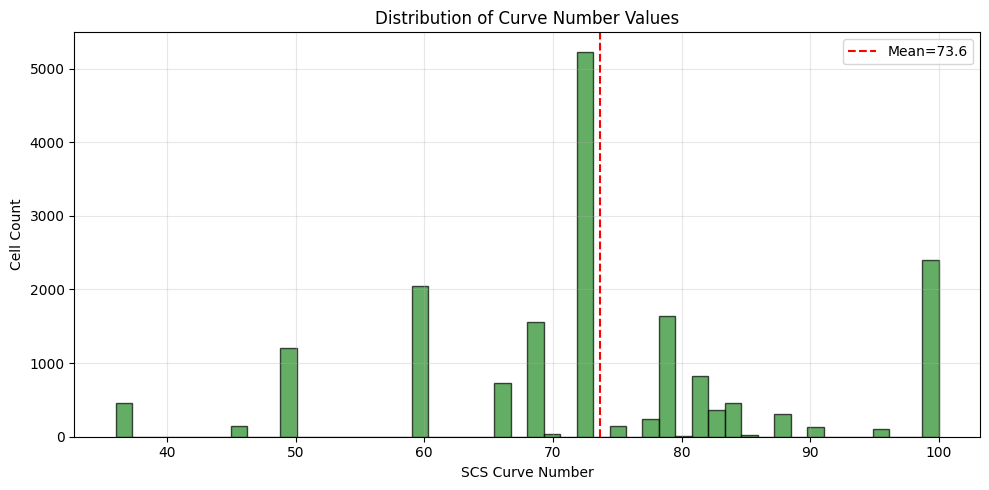

In [8]:
cn = HdfInfiltration.get_preprocessed_infiltration(geom_hdf, variable='Curve Number')
assert len(cn) > 0, 'Expected preprocessed Curve Number values.'
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    cn['value'],
    bins=50,
    edgecolor='black',
    alpha=0.7,
    color='forestgreen',
)
ax.set_xlabel('SCS Curve Number')
ax.set_ylabel('Cell Count')
ax.set_title('Distribution of Curve Number Values')
ax.axvline(
    cn['value'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean={cn['value'].mean():.1f}",
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close(fig)

## Infiltration Region Polygon Regression

The bundled example project exposes preprocessed infiltration cell values, but it does not contain geometry-level infiltration override polygons. This regression cell builds a minimal geometry HDF fixture with one exterior ring and one interior ring so the notebook exercises `HdfInfiltration.get_infiltration_region_polygons()` on the multi-ring path.

In [9]:
fixture_dir = repo_root / 'working' / 'notebook_runs'
fixture_dir.mkdir(parents=True, exist_ok=True)
fixture_hdf = fixture_dir / '211_infiltration_multipart_fixture.g01.hdf'

outer_ring = np.array(
    [
        [0.0, 0.0],
        [4.0, 0.0],
        [4.0, 4.0],
        [0.0, 4.0],
        [0.0, 0.0],
    ],
    dtype=float,
)
inner_ring = np.array(
    [
        [1.0, 1.0],
        [1.0, 3.0],
        [3.0, 3.0],
        [3.0, 1.0],
        [1.0, 1.0],
    ],
    dtype=float,
)
polygon_points = np.vstack([outer_ring, inner_ring])
polygon_parts = np.array(
    [
        [0, len(outer_ring)],
        [len(outer_ring), len(inner_ring)],
    ],
    dtype=np.int32,
)
polygon_info = np.array(
    [[0, len(polygon_points), 0, len(polygon_parts)]],
    dtype=np.int32,
)
attributes = np.array(
    [(b'MultiRingRegion',)],
    dtype=np.dtype([('Name', 'S32')]),
)

with h5py.File(fixture_hdf, 'w') as hdf_file:
    geometry = hdf_file.create_group('Geometry')
    infiltration = geometry.create_group('Infiltration')
    infiltration.create_dataset('Attributes', data=attributes)
    infiltration.create_dataset('Polygon Info', data=polygon_info)
    infiltration.create_dataset('Polygon Parts', data=polygon_parts)
    infiltration.create_dataset('Polygon Points', data=polygon_points)

regions_gdf = HdfInfiltration.get_infiltration_region_polygons(fixture_hdf)
assert len(regions_gdf) == 1, 'Expected one infiltration region from regression fixture.'
fixture_geom = regions_gdf.geometry.iloc[0]
assert fixture_geom.geom_type == 'Polygon'
assert len(fixture_geom.interiors) == 1, 'Expected one interior ring.'
assert np.isclose(fixture_geom.area, 12.0), f'Unexpected polygon area: {fixture_geom.area}'
print(f'Regression fixture: {fixture_hdf.name}')
print(f'Geometry type: {fixture_geom.geom_type}')
print(f'Interior rings: {len(fixture_geom.interiors)}')
print(f'Area: {fixture_geom.area:.2f}')
regions_gdf[['region_id', 'Name', 'geometry']]

Regression fixture: 211_infiltration_multipart_fixture.g01.hdf
Geometry type: Polygon
Interior rings: 1
Area: 12.00


,region_id,Name,geometry
0,0,MultiRingRegion,"POLYGON ((0 0, 4 0, 4 4, 0 4, 0 0), (1 1, 1 3,..."


## Key Takeaways

- `BaldEagleCrkMulti2D` provides a reproducible real-project source for preprocessed Manning's N and infiltration values.
- The notebook now includes an executable regression for multi-ring infiltration override polygons.
- Running this notebook end to end validates both the example workflow and the polygon-construction fix.